Imports + Data Collection

In [239]:
import pandas as pd
import requests
from io import StringIO

def read_socrata_data(url, params=None):
    response = requests.get(url, params=params)
    response.raise_for_status()
    return pd.read_csv(StringIO(response.text))

data_311 = read_socrata_data(
    "https://data.cityofnewyork.us/resource/erm2-nwe9.csv",
    {
        "$where": "created_date >= '2026-01-01T00:00:00'",
        "$limit": 500000,  
        "$order": "created_date DESC"
    }
)

from datetime import datetime, timedelta

thirty_days_ago = (datetime.now() - timedelta(days=30)).strftime("%Y-%m-%dT%H:%M:%S")

data_crime = read_socrata_data(
    "https://data.cityofnewyork.us/resource/5uac-w243.csv",
    {
        "$where": f"cmplnt_fr_dt >= '{thirty_days_ago}'",
        "$limit": 100000,
        "$order": "cmplnt_fr_dt DESC"
    }
)

data_crashes = read_socrata_data(
    "https://data.cityofnewyork.us/resource/h9gi-nx95.csv",
    {
        "$where": f"crash_date >= '{thirty_days_ago}'",
        "$limit": 100000,
        "$order": "crash_date DESC"
    }
)

data_traffic = read_socrata_data(
    "https://data.cityofnewyork.us/resource/7ym2-wayt.csv",
    {"$limit": 500000}
)

data_subway = read_socrata_data(
    "https://data.ny.gov/resource/5wq4-mkjj.csv",
    {"$limit": 500000}
)

data_pedestrian = read_socrata_data(
    "https://data.cityofnewyork.us/resource/cqsj-cfgu.csv",
    {"$limit": 500000}
)

Bluesky Posts Collection

In [128]:
from atproto import Client
from datetime import datetime, timedelta, timezone
import pandas as pd
import time

client = Client()
client.login("ni2-04.bsky.social", "p277-5mkx-v6qs-xedy")

since_time = (datetime.now(timezone.utc) - timedelta(hours=24)).isoformat().replace("+00:00", "Z")

queries = [
    "NYC noise",
    "New York City noise",
    "New York noise",
    "New York City traffic",
    "New York City construction",
    "New York City crowded",
    "New York City subway",
    "New York City event",
    "New York City protest",
    "NYC traffic",
    "NYC construction",
    "NYC crowded",
    "NYC subway",
    "NYC event",
    "NYC protest"
]

unique_posts = {}

for query in queries:
    cursor = None

    while len(unique_posts) < 100:
        params = {
            "q": query,
            "limit": 100,
            "since": since_time,
            "sort": "latest",
            "lang": "en"
        }

        if cursor:
            params["cursor"] = cursor

        response = client.app.bsky.feed.search_posts(params)

        if not response.posts:
            break

        for post in response.posts:
            text_clean = post.record.text.lower().strip()
            text_clean = " ".join(text_clean.split())

            if text_clean not in unique_posts:
                unique_posts[text_clean] = {
                    "query": query,
                    "text": post.record.text,
                    "created_at": post.record.created_at,
                    "author": post.author.display_name,
                    "author_username": post.author.handle,
                    "uri": post.uri,
                    "likes": post.like_count,
                    "replies": post.reply_count,
                    "reposts": post.repost_count
                }

            if len(unique_posts) >= 100:
                break

        cursor = response.cursor

        if not cursor:
            break

        time.sleep(1)

    if len(unique_posts) >= 100:
        break

df_bluesky = pd.DataFrame(unique_posts.values())

print(df_bluesky.shape)
print(df_bluesky.head())

(100, 9)
                   query                                               text  \
0    New York City noise  Don’t like the noise? Then get ready to pack y...   
1         New York noise  @mayor.nyc.gov and his team goes above and bey...   
2  New York City traffic  New York risk level Low. Latest 48h brief top ...   
3  New York City traffic                                          Test post   
4  New York City traffic  A, Rockaway Park Shuttle trains are delayed in...   

                 created_at                          author  \
0  2026-06-01T02:54:54.699Z         Shinku! | COMMS OPEN🦊🔮✨   
1  2026-05-31T23:45:59.854Z                            None   
2  2026-06-01T02:00:31.435Z                       Citizen X   
3  2026-05-31T22:20:42.163Z                        Sharon Z   
4  2026-05-31T22:08:26.000Z  MTA Subway Alerts (Unofficial)   

                              author_username  \
0                    shinkumancer.bsky.social   
1                      angrylibra.bsky.

Data Cleaning

In [129]:
def clean_columns(df):
    df = df.copy()
    df.columns = (
        df.columns
        .str.lower()
        .str.strip()
        .str.replace(" ", "_")
        .str.replace("-", "_")
    )
    return df

In [130]:
data_311 = clean_columns(data_311)
data_crime = clean_columns(data_crime)
data_traffic = clean_columns(data_traffic)
data_subway = clean_columns(data_subway)
data_crashes = clean_columns(data_crashes)
data_pedestrian = clean_columns(data_pedestrian)
data_bluesky = clean_columns(df_bluesky)

In [131]:
data_311['created_date'] = pd.to_datetime(data_311['created_date'], errors='coerce')

data_311['latitude'] = pd.to_numeric(data_311['latitude'], errors='coerce')
data_311['longitude'] = pd.to_numeric(data_311['longitude'], errors='coerce')

data_311['unique_key'] = data_311['unique_key'].astype(str)

data_311['incident_zip'] = (
    pd.to_numeric(data_311['incident_zip'], errors='coerce')
    .astype('Int64')
    .astype(str)
    .replace('<NA>', pd.NA)
)

data_311['council_district'] = pd.to_numeric(data_311['council_district'], errors='coerce')
data_311["x_coordinate_state_plane"] = pd.to_numeric(data_311["x_coordinate_state_plane"], errors="coerce")
data_311["y_coordinate_state_plane"] = pd.to_numeric(data_311["y_coordinate_state_plane"], errors="coerce")

text_cols = ["agency", "complaint_type", "descriptor", "location_type", "status", "borough", "city"]

for col in text_cols:
    if col in data_311.columns:
        data_311[col] = data_311[col].astype(str).str.strip().str.lower()

data_311 = data_311.dropna(subset=["created_date", "latitude", "longitude"])
data_311 = data_311.drop_duplicates(subset=["unique_key"])

In [132]:
data_crime["cmplnt_fr_dt"] = pd.to_datetime(data_crime["cmplnt_fr_dt"], errors="coerce")

data_crime["latitude"] = pd.to_numeric(data_crime["latitude"], errors="coerce")
data_crime["longitude"] = pd.to_numeric(data_crime["longitude"], errors="coerce")

data_crime["cmplnt_num"] = data_crime["cmplnt_num"].astype(str)
data_crime["addr_pct_cd"] = data_crime["addr_pct_cd"].astype(str).str.replace(".0", "", regex=False)
data_crime["ky_cd"] = data_crime["ky_cd"].astype(str).str.replace(".0", "", regex=False)

data_crime["pd_cd"] = (
    pd.to_numeric(data_crime["pd_cd"], errors="coerce")
    .astype("Int64")
    .astype(str)
    .replace("<NA>", pd.NA)
)

text_cols = [
    "ofns_desc", "pd_desc", "crm_atpt_cptd_cd", "law_cat_cd",
    "boro_nm", "loc_of_occur_desc", "prem_typ_desc",
    "juris_desc", "patrol_boro", "station_name"
]

for col in text_cols:
    if col in data_crime.columns:
        data_crime[col] = data_crime[col].astype(str).str.strip().str.lower()

data_crime = data_crime.dropna(subset=["cmplnt_fr_dt", "latitude", "longitude"])
data_crime = data_crime.drop_duplicates(subset=["cmplnt_num"])

In [133]:
data_bluesky["created_at"] = pd.to_datetime(data_bluesky["created_at"], errors="coerce")
data_bluesky["uri"] = data_bluesky["uri"].astype(str)
for col in ["likes", "replies", "reposts"]:
    if col in data_bluesky.columns:
        data_bluesky[col] = pd.to_numeric(data_bluesky[col], errors="coerce").fillna(0).astype(int)
data_bluesky["engagement"] = (
    data_bluesky["likes"] + data_bluesky["replies"] + data_bluesky["reposts"]
)
text_cols = ["query", "text", "author", "author_username"]

for col in text_cols:
    if col in data_bluesky.columns:
        data_bluesky[col] = data_bluesky[col].astype(str).str.strip()
data_bluesky = data_bluesky.drop_duplicates(subset=["uri"])

In [134]:
data_subway["transit_timestamp"] = pd.to_datetime(
    data_subway["transit_timestamp"],
    errors="coerce"
)

data_subway["latitude"] = pd.to_numeric(data_subway["latitude"], errors="coerce")
data_subway["longitude"] = pd.to_numeric(data_subway["longitude"], errors="coerce")
data_subway["station_complex_id"] = data_subway["station_complex_id"].astype(str)
for col in ["ridership", "transfers"]:
    if col in data_subway.columns:
        data_subway[col] = pd.to_numeric(data_subway[col], errors="coerce").fillna(0)
text_cols = [
    "transit_mode",
    "station_complex",
    "borough",
    "payment_method",
    "fare_class_category"
]

for col in text_cols:
    if col in data_subway.columns:
        data_subway[col] = data_subway[col].astype(str).str.strip().str.lower()
data_subway = data_subway.dropna(subset=["latitude", "longitude"])

In [135]:
data_crashes["crash_date"] = pd.to_datetime(data_crashes["crash_date"], errors="coerce")
if "crash_time" in data_crashes.columns:
    data_crashes["crash_time"] = data_crashes["crash_time"].astype(str).str.strip()
data_crashes["latitude"] = pd.to_numeric(data_crashes["latitude"], errors="coerce")
data_crashes["longitude"] = pd.to_numeric(data_crashes["longitude"], errors="coerce")
data_crashes["collision_id"] = data_crashes["collision_id"].astype(str)

if "zip_code" in data_crashes.columns:
    data_crashes["zip_code"] = pd.to_numeric(data_crashes["zip_code"], errors="coerce").astype("Int64").astype(str)
count_cols = [
    "number_of_persons_injured",
    "number_of_persons_killed",
    "number_of_pedestrians_injured",
    "number_of_pedestrians_killed",
    "number_of_cyclist_injured",
    "number_of_cyclist_killed",
    "number_of_motorist_injured",
    "number_of_motorist_killed"
]

for col in count_cols:
    if col in data_crashes.columns:
        data_crashes[col] = pd.to_numeric(data_crashes[col], errors="coerce").fillna(0).astype(int)
text_cols = [
    "borough",
    "on_street_name",
    "off_street_name",
    "cross_street_name",
    "contributing_factor_vehicle_1",
    "contributing_factor_vehicle_2",
    "contributing_factor_vehicle_3",
    "contributing_factor_vehicle_4",
    "contributing_factor_vehicle_5",
    "vehicle_type_code1",
    "vehicle_type_code2",
    "vehicle_type_code_3",
    "vehicle_type_code_4",
    "vehicle_type_code_5"
]

for col in text_cols:
    if col in data_crashes.columns:
        data_crashes[col] = data_crashes[col].astype(str).str.strip().str.lower()
data_crashes = data_crashes.dropna(subset=["latitude", "longitude"])
data_crashes = data_crashes.drop_duplicates(subset=["collision_id"])

In [136]:
if "requestid" in data_traffic.columns:
    data_traffic["requestid"] = data_traffic["requestid"].astype(str)

if "segmentid" in data_traffic.columns:
    data_traffic["segmentid"] = data_traffic["segmentid"].astype(str)

for col in ["yr", "m", "d", "hh", "mm", "vol"]:
    if col in data_traffic.columns:
        data_traffic[col] = pd.to_numeric(data_traffic[col], errors="coerce")

if all(col in data_traffic.columns for col in ["yr", "m", "d", "hh", "mm"]):
    data_traffic["traffic_datetime"] = pd.to_datetime(
        dict(
            year=data_traffic["yr"],
            month=data_traffic["m"],
            day=data_traffic["d"],
            hour=data_traffic["hh"],
            minute=data_traffic["mm"]
        ),
        errors="coerce"
    )
text_cols = ["boro", "street", "fromst", "tost", "direction"]

for col in text_cols:
    if col in data_traffic.columns:
        data_traffic[col] = data_traffic[col].astype(str).str.strip().str.lower()

if "wktgeom" in data_traffic.columns:
    data_traffic["wktgeom"] = data_traffic["wktgeom"].astype(str).str.strip()

In [137]:
if "objectid" in data_pedestrian.columns:
    data_pedestrian["objectid"] = data_pedestrian["objectid"].astype(str)

if "loc" in data_pedestrian.columns:
    data_pedestrian["loc"] = data_pedestrian["loc"].astype(str)

text_cols = ["borough", "street_nam", "from_stree", "to_street", "iex"]

for col in text_cols:
    if col in data_pedestrian.columns:
        data_pedestrian[col] = data_pedestrian[col].astype(str).str.strip().str.lower()
if "the_geom" in data_pedestrian.columns:
    data_pedestrian["the_geom"] = data_pedestrian["the_geom"].astype(str).str.strip()

id_cols = [
    "the_geom",
    "objectid",
    "loc",
    "borough",
    "street_nam",
    "from_stree",
    "to_street",
    "iex"
]

count_cols = [col for col in data_pedestrian.columns if col not in id_cols]

for col in count_cols:
    data_pedestrian[col] = pd.to_numeric(data_pedestrian[col], errors="coerce")

Save Cleaned Data to Postgres DB

In [138]:
from sqlalchemy import create_engine

engine = create_engine("postgresql+psycopg://nihal@localhost:5432/hereabouts")

In [139]:
data_bluesky.to_sql("bluesky", engine, if_exists="replace", index=False)
data_311.to_sql("noise_complaints", engine, if_exists="replace", index=False)
data_crime.to_sql("crime", engine, if_exists="replace", index=False)
data_traffic.to_sql("traffic", engine, if_exists="replace", index=False)
data_subway.to_sql("subway", engine, if_exists="replace", index=False)
data_crashes.to_sql("crashes", engine, if_exists="replace", index=False)
data_pedestrian.to_sql("pedestrian", engine, if_exists="replace", index=False)

-1

EDA

In [140]:
datasets = {
    "311": data_311,
    "crime": data_crime,
    "traffic": data_traffic,
    "subway": data_subway,
    "crashes": data_crashes,
    "pedestrian": data_pedestrian,
    "bluesky": data_bluesky
}

for name, df in datasets.items():
    print("\n", name)
    print("shape:", df.shape)
    print(df.isna().mean().sort_values(ascending=False).head(10))


 311
shape: (48694, 44)
road_ramp                   0.999384
taxi_company_borough        0.999281
bridge_highway_direction    0.999199
facility_type               0.997679
due_date                    0.997166
bridge_highway_segment      0.996858
bridge_highway_name         0.996837
taxi_pick_up_location       0.987678
vehicle_type                0.944942
descriptor_2                0.645377
dtype: float64

 crime
shape: (133107, 36)
housing_psa         0.933445
transit_district    0.930995
cmplnt_to_dt        0.039885
pd_cd               0.000413
latitude            0.000000
longitude           0.000000
y_coord_cd          0.000000
x_coord_cd          0.000000
vic_sex             0.000000
pd_desc             0.000000
dtype: float64

 traffic
shape: (500000, 15)
requestid    0.0
boro         0.0
yr           0.0
m            0.0
d            0.0
hh           0.0
mm           0.0
vol          0.0
segmentid    0.0
wktgeom      0.0
dtype: float64

 subway
shape: (500000, 12)
transit_times

In [141]:
#Noise Complaints
import matplotlib.pyplot as plt
data_311["complaint_type"].value_counts().head(25)

complaint_type
illegal parking               8218
noise - residential           4797
noise - street/sidewalk       3485
blocked driveway              2386
unsanitary condition          1910
street condition              1444
dirty condition               1074
plumbing                      1034
abandoned vehicle             1032
noise - vehicle                923
water system                   902
paint/plaster                  892
noise - commercial             874
heat/hot water                 832
encampment                     825
noise                          811
overgrown tree/branches        755
door/window                    680
damaged tree                   624
maintenance or facility        599
general                        592
water leak                     584
homeless person assistance     581
illegal dumping                578
sewer                          515
Name: count, dtype: int64

In [142]:
data_311["borough"].value_counts()

borough
brooklyn         15868
queens           12120
manhattan         9924
bronx             8847
staten island     1934
unspecified          1
Name: count, dtype: int64

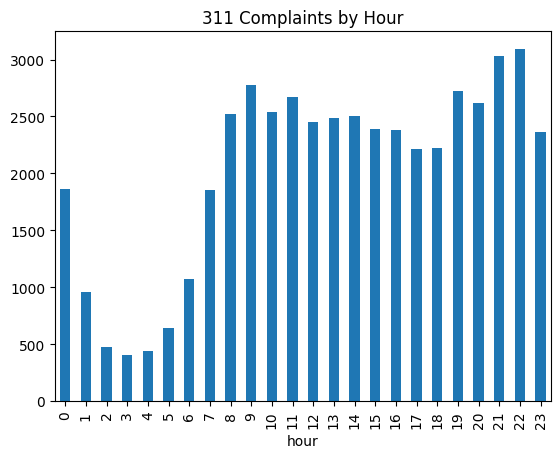

In [143]:
data_311["hour"] = data_311["created_date"].dt.hour
data_311.groupby("hour").size().plot(kind="bar", title="311 Complaints by Hour")
plt.show()

/var/folders/5y/wcgww58j65v99lffgqfdyl600000gn/T/ipykernel_52207/2861115851.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  noise_311["hour"] = noise_311["created_date"].dt.hour


<Axes: title={'center': 'Noise Complaints by Hour'}, xlabel='hour'>

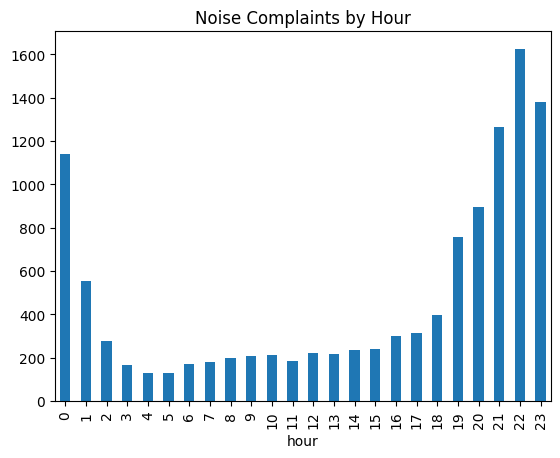

In [144]:
noise_311 = data_311[data_311["complaint_type"].str.contains("noise", case=False, na=False)]
noise_311["hour"] = noise_311["created_date"].dt.hour
noise_311.groupby("hour").size().plot(kind="bar", title="Noise Complaints by Hour")

In [145]:
#Crime
data_crime["law_cat_cd"].value_counts()

law_cat_cd
misdemeanor    69799
felony         41659
violation      21649
Name: count, dtype: int64

In [146]:
data_crime["boro_nm"].value_counts()

boro_nm
brooklyn         38344
manhattan        30592
bronx            30371
queens           28295
staten island     5129
(null)             376
Name: count, dtype: int64

<Axes: title={'center': 'Crime by Hour'}, xlabel='hour'>

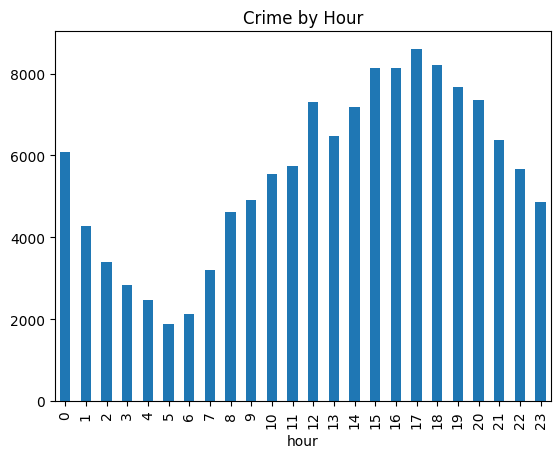

In [147]:
data_crime["crime_datetime"] = pd.to_datetime(
    data_crime["cmplnt_fr_dt"].astype(str) + " " + data_crime["cmplnt_fr_tm"].astype(str),
    errors="coerce"
)

data_crime["hour"] = data_crime["crime_datetime"].dt.hour
data_crime.groupby("hour").size().plot(kind="bar", title="Crime by Hour")

In [148]:
data_crime["ofns_desc"].value_counts().head(20)

ofns_desc
petit larceny                      23136
harrassment 2                      20226
assault 3 & related offenses       13678
grand larceny                      10209
criminal mischief & related of      7656
vehicle and traffic laws            7216
felony assault                      6630
miscellaneous penal law             4901
dangerous drugs                     4879
off. agnst pub ord sensblty &       4160
other offenses related to theft     4125
robbery                             2945
grand larceny of motor vehicle      2687
burglary                            2611
offenses against public admini      2398
sex crimes                          2394
dangerous weapons                   2042
forgery                             1614
administrative code                 1323
other state laws                    1257
Name: count, dtype: int64

In [149]:
#Crashes
data_crashes["borough"].value_counts()

borough
nan              137385
brooklyn         112195
queens            88855
bronx             56673
manhattan         53501
staten island     11996
Name: count, dtype: int64

<Axes: title={'center': 'Crashes by Hour'}, xlabel='hour'>

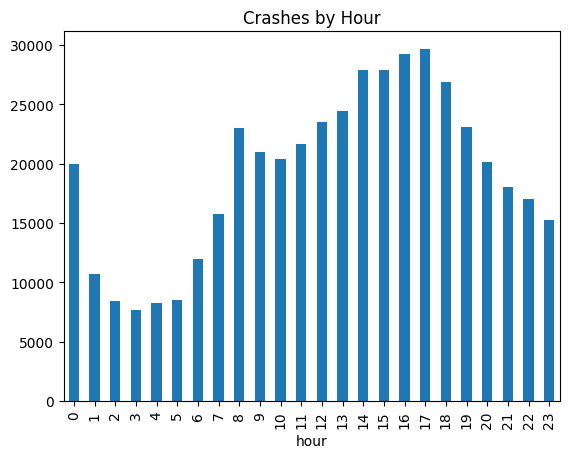

In [150]:
data_crashes["crash_datetime"] = pd.to_datetime(
    data_crashes["crash_date"].astype(str) + " " + data_crashes["crash_time"].astype(str),
    errors="coerce"
)

data_crashes["hour"] = data_crashes["crash_datetime"].dt.hour
data_crashes.groupby("hour").size().plot(kind="bar", title="Crashes by Hour")

In [151]:
data_crashes["contributing_factor_vehicle_1"].value_counts().head(20)

contributing_factor_vehicle_1
unspecified                                              115631
driver inattention/distraction                           115560
failure to yield right-of-way                             32120
following too closely                                     27406
passing or lane usage improper                            19419
passing too closely                                       17189
backing unsafely                                          15612
unsafe speed                                              15290
other vehicular                                           13163
traffic control disregarded                               12291
turning improperly                                        10245
driver inexperience                                        8953
unsafe lane changing                                       8818
alcohol involvement                                        7570
reaction to uninvolved vehicle                             5742
pedestrian

In [152]:
data_crashes.groupby("borough")[["number_of_persons_injured", "number_of_pedestrians_injured", "number_of_cyclist_injured"]].sum().sort_values(by = "number_of_persons_injured", ascending=False)

,number_of_persons_injured,number_of_pedestrians_injured,number_of_cyclist_injured
borough,,,
nan,73614,8455,5320
brooklyn,52375,9951,6474
queens,39349,7342,3297
bronx,25563,5113,2015
manhattan,21742,5570,4964
staten island,5305,790,215


In [153]:
#subway
data_subway.groupby("borough")["ridership"].sum().sort_values(ascending=False)

borough
manhattan        12671428.0
brooklyn          5207751.0
queens            3482647.0
bronx             1664932.0
staten island       41600.0
Name: ridership, dtype: float64

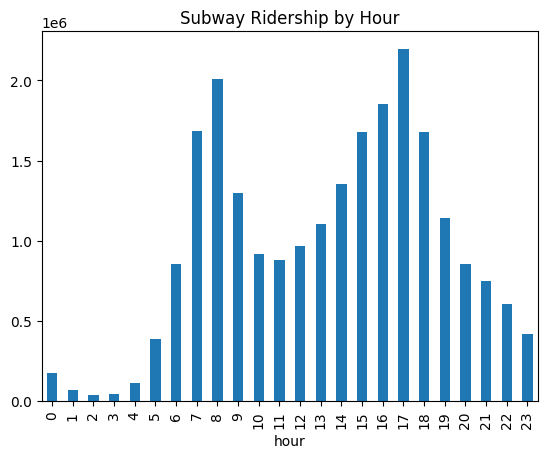

In [154]:
data_subway["hour"] = data_subway["transit_timestamp"].dt.hour
data_subway.groupby("hour")["ridership"].sum().plot(kind="bar", title="Subway Ridership by Hour")
plt.show()


In [155]:
data_subway.groupby("station_complex")["ridership"].sum().sort_values(ascending=False).head(20)

station_complex
times sq-42 st/port authority bus terminal (1,2,3,7,a,c,e,n,q,r,w,s)    840001.0
grand central-42 st (4,5,6,7,s)                                         644443.0
34 st-herald sq (b,d,f,m,n,q,r,w)                                       459944.0
14 st-union sq (4,5,6,l,n,q,r,w)                                        418636.0
fulton st (2,3,4,5,a,c,j,z)                                             373049.0
34 st-penn station (a,c,e)                                              349521.0
34 st-penn station (1,2,3)                                              314304.0
59 st-columbus circle (1,a,c,b,d)                                       289449.0
flushing-main st (7)                                                    269369.0
jackson hts-roosevelt av/74 st-broadway (7,e,f,m,r)                     250607.0
lexington av/51-53 sts (6,e,f)                                          245751.0
chambers st/wtc/park place/cortlandt st (2,3,a,c,e,r,w)                 242618.0
47-50 sts-ro

In [156]:
data_subway.groupby("station_complex")["transfers"].sum().sort_values(ascending=False).head(20)

station_complex
flushing-main st (7)                                   85491.0
jamaica center-parsons/archer (e,j,z)                  47071.0
kew gardens-union tpke (e,f)                           33817.0
jackson hts-roosevelt av/74 st-broadway (7,e,f,m,r)    32672.0
jamaica-179 st (f)                                     27124.0
lexington av/59 st (4,5,6,n,r,w)                       19764.0
forest hills-71 av (e,f,m,r)                           19212.0
whitehall st-south ferry (1,r,w)                       18602.0
flatbush av-brooklyn college (2,5)                     16206.0
kings hwy (b,q)                                        15319.0
sutphin blvd-archer av-jfk airport (e,j,z)             14859.0
woodhaven blvd (m,r)                                   14743.0
grand av-newtown (m,r)                                 14272.0
crown hts-utica av (3,4)                               13342.0
canarsie-rockaway pkwy (l)                             13113.0
86 st (r)                              

In [157]:
#traffic
data_traffic.groupby("boro")["vol"].sum().sort_values(ascending=False)

boro
queens           13242819
manhattan        12789378
brooklyn         12418154
bronx             9747420
staten island     2779944
Name: vol, dtype: int64

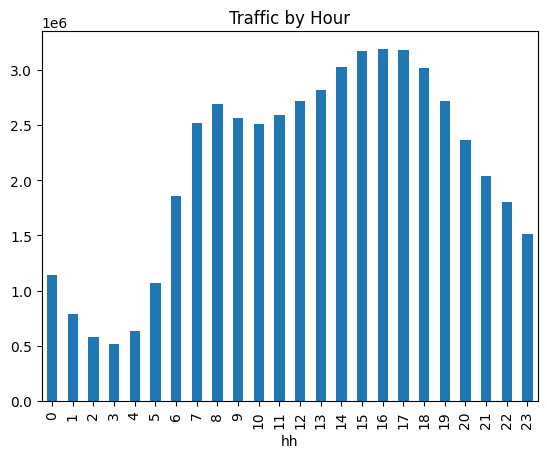

In [158]:
data_traffic.groupby("hh")["vol"].sum().plot(kind="bar", title="Traffic by Hour")
plt.show()

In [159]:
data_traffic.groupby("street")["vol"].sum().sort_values(ascending=False).head(20)

street
eastern blvd br                            806508
hamilton avenue bridge                     789339
hook creek bridge                          753769
belt parkway exit 25 a nb                  727712
belt parkway                               706703
broadway                                   620913
flatbush avenue                            606866
university heights bridge                  590865
f d r drive                                581216
sunrise highway                            559231
brooklyn bridge                            532295
alexander hamilton bridge                  474707
n/b major deegan expwy @ city line         467989
new england thruway                        429526
avenue of the americas                     411071
brooklyn queens expressway                 375822
linden boulevard                           369784
w/b eastern blvd bridge@bronx river ave    353487
s/b henry hudson parkway @ city line       351574
f d r dr                                   

In [160]:
#pedestrian
data_pedestrian.columns

Index(['the_geom', 'objectid', 'loc', 'borough', 'street_nam', 'from_stree',
       'to_street', 'iex', 'may_07_am', 'may_07_pm',
       ...
       'june_24_md', 'oct24_am', 'oct24_pm', 'oct24_md', 'may25_am',
       'may25_pm', 'may25_md', 'oct25_am', 'oct25_pm', 'oct25_md'],
      dtype='object', length=116)

In [161]:
data_pedestrian

,the_geom,objectid,loc,borough,street_nam,from_stree,to_street,iex,may_07_am,may_07_pm,...,june_24_md,oct24_am,oct24_pm,oct24_md,may25_am,may25_pm,may25_md,oct25_am,oct25_pm,oct25_md
0,POINT (-73.90459140730678 40.87919896648574),1,1,bronx,broadway,west 231st street,naples terrace,n,1189.0,4094.0,...,2052.0,1031.0,4097.0,2229.0,811.0,2420.0,2224.0,753.0,3910.0,2473.0
1,POINT (-73.92188432870218 40.82662794123292),2,2,bronx,east 161st street,gra concourse,sheridan avenue,y,1511.0,3184.0,...,1493.0,3016.0,4685.0,1655.0,2928.0,4168.0,2468.0,2655.0,4710.0,1486.0
2,POINT (-73.89535781584335 40.86215460031517),3,3,bronx,east fordham road,valentine avenue,tiebout avenue,y,1832.0,12311.0,...,3819.0,1689.0,6405.0,4417.0,1599.0,4936.0,4688.0,1765.0,7176.0,4672.0
3,POINT (-73.87892467324478 40.8812869959873),4,4,bronx,east gun hill road,bainbridge avenue,rochambeau avenue,n,764.0,2673.0,...,1190.0,1495.0,2474.0,1073.0,1261.0,1779.0,1133.0,1565.0,2288.0,1214.0
4,POINT (-73.88956389732787 40.844636776717664),5,5,bronx,east tremont avenue,prospect avenue,clinton avenue,n,650.0,2538.0,...,1563.0,725.0,2329.0,1888.0,714.0,1585.0,1522.0,777.0,2512.0,1695.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,POINT (-73.9331330278822 40.814131067977755),110,110,harlem river bridges,madison avenue bridge,midpoint,nan,n,145.0,305.0,...,187.0,364.0,487.0,149.0,310.0,464.0,207.0,279.0,390.0,136.0
110,POINT (-73.93252967704326 40.807554810103504),111,111,harlem river bridges,third avenue bridge,midpoint,nan,n,49.0,126.0,...,50.0,113.0,218.0,65.0,80.0,292.0,78.0,102.0,286.0,80.0
111,POINT (-73.92896107917844 40.803769279822106),112,112,harlem river bridges,willis avenue bridge,midpoint,nan,n,57.0,118.0,...,73.0,125.0,162.0,92.0,105.0,236.0,71.0,143.0,229.0,135.0
112,POINT (-73.92785197149036 40.80034506063934),113,113,harlem river bridges,triborough bridge (manhattan span),midpoint,nan,n,17.0,35.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [162]:
id_cols = ['the_geom', 'objectid', 'loc', 'borough', 'street_nam', 'from_stree',
       'to_street', 'iex']
count_cols = [col for col in data_pedestrian.columns if col not in id_cols]

data_pedestrian['avg_ped_count'] = data_pedestrian[count_cols].mean(axis=1)

data_pedestrian[['borough', 'street_nam', 'avg_ped_count']].sort_values(by='avg_ped_count',ascending=False).head(20)

/var/folders/5y/wcgww58j65v99lffgqfdyl600000gn/T/ipykernel_52207/3393367791.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_pedestrian['avg_ped_count'] = data_pedestrian[count_cols].mean(axis=1)


,borough,street_nam,avg_ped_count
56,manhattan,west 34th street,15806.314815
50,manhattan,seventh avenue,14163.429907
64,manhattan,fifth avenue,11653.685714
44,manhattan,fifth avenue,11375.981308
43,manhattan,eighth avenue,11371.942857
65,manhattan,sixth avenue,10452.495238
41,manhattan,east 42 street,9573.851852
91,queens,roosevelt avenue,8430.278846
66,manhattan,seventh avenue,7827.240385
67,manhattan,broadway,7435.972222


In [163]:
#bluesky
data_bluesky["query"].value_counts()

query
New York City subway     64
New York City event      13
NYC traffic               8
New York City traffic     4
NYC crowded               3
New York City protest     2
NYC construction          2
New York City noise       1
New York noise            1
New York City crowded     1
NYC subway                1
Name: count, dtype: int64

In [164]:
data_bluesky.groupby("query")["engagement"].sum().sort_values(ascending=False)

query
NYC traffic              43
New York City event      28
New York City traffic    13
NYC subway                8
NYC crowded               5
NYC construction          3
New York noise            3
New York City crowded     2
New York City noise       1
New York City protest     0
New York City subway      0
Name: engagement, dtype: int64

<Axes: title={'center': 'BlueSky Engagement by Hour'}, xlabel='hour'>

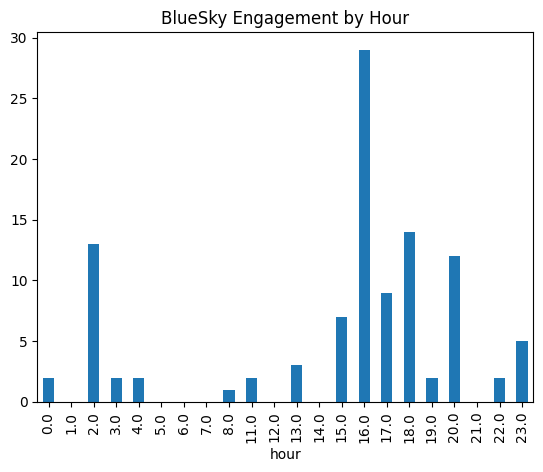

In [165]:
data_bluesky["hour"] = data_bluesky["created_at"].dt.hour

data_bluesky.groupby("hour")["engagement"].sum().plot(kind="bar", title="BlueSky Engagement by Hour")

In [166]:
data_bluesky[['query','text', 'engagement']].sample(10)

,query,text,engagement
42,New York City subway,Uptown F trains are delayed while we address a...,0
72,New York City event,📸 Patrick Dempsey with onenof the attendees at...,2
92,NYC traffic,hey how you doing...dang i finally encountered...,0
9,New York City subway,A trains are delayed in both directions while ...,0
74,New York City event,"Much better than UFC Cage Matches\n\n""‘No King...",2
4,New York City traffic,"A, Rockaway Park Shuttle trains are delayed in...",0
26,New York City subway,5 trains are delayed entering and leaving East...,0
56,New York City subway,"Uptown A, D trains are running with delays whi...",0
35,New York City subway,Wakefield-241 St-bound 2 trains are delayed wh...,0
77,New York City event,Muslim Delegation Makes Israel Day Parade Debu...,0


In [167]:
#product eda
data_traffic["hour"] = data_traffic["hh"]
data_crashes["crash_datetime"] = pd.to_datetime(
    data_crashes["crash_date"].astype(str) + " " + data_crashes["crash_time"].astype(str),
    errors="coerce"
)

data_crashes["hour"] = data_crashes["crash_datetime"].dt.hour

noise_hour = noise_311.groupby("hour").size().reset_index(name="noise_count")
crashes_hour = data_crashes.groupby("hour").size().reset_index(name="crashes_count")
traffic_hour = data_traffic.groupby("hour")["vol"].sum().reset_index(name="traffic_count")

hourly_activity = pd.merge(noise_hour, crashes_hour, on="hour", how="outer")
hourly_activity = pd.merge(hourly_activity, traffic_hour, on="hour", how="outer")
hourly_activity.fillna(0, inplace=True)

In [168]:
cols_to_scale = ["noise_count", "crashes_count", "traffic_count"]

for col in cols_to_scale:
    hourly_activity[col + "_scaled"] = hourly_activity[col] / hourly_activity[col].max()

hourly_activity["risk_score"] = (0.4*hourly_activity["traffic_count_scaled"]) + (0.3*hourly_activity["crashes_count_scaled"]) + (0.3*hourly_activity["noise_count_scaled"])

hourly_activity.sort_values(by='risk_score', ascending=False)

,hour,noise_count,crashes_count,traffic_count,noise_count_scaled,crashes_count_scaled,traffic_count_scaled,risk_score
17,17,316,29665,3177592,0.194462,1.000000,0.996916,0.757105
16,16,299,29239,3187422,0.184000,0.985640,1.000000,0.750892
15,15,242,27922,3165684,0.148923,0.941244,0.993180,0.724322
18,18,395,26882,3013900,0.243077,0.906186,0.945560,0.723003
19,19,755,23112,2715805,0.464615,0.779100,0.852038,0.713930
14,14,236,27889,3023428,0.145231,0.940131,0.948550,0.705029
22,22,1625,17044,1803847,1.000000,0.574549,0.565927,0.698735
21,21,1264,18025,2036017,0.777846,0.607618,0.638766,0.671146
20,20,894,20108,2360446,0.550154,0.677836,0.740550,0.664617
13,13,218,24423,2816301,0.134154,0.823293,0.883567,0.640661


Mapping data to neighborhood boundaries

In [169]:
import geopandas as gpd
from shapely import wkt
nta_url = "https://data.cityofnewyork.us/resource/9nt8-h7nd.geojson"

response = requests.get(nta_url, timeout=60)
response.raise_for_status()

with open("nyc_nta.geojson", "w") as f:
    f.write(response.text)

nta = gpd.read_file("nyc_nta.geojson")
nta = nta.to_crs(epsg=4326)

In [170]:
gdf_311 = gpd.GeoDataFrame(data_311, geometry=gpd.points_from_xy(data_311.longitude, data_311.latitude), crs="EPSG:4326")
gdf_311 = gpd.sjoin(gdf_311, nta, how="left", predicate="within")

gdf_crime = gpd.GeoDataFrame(data_crime, geometry=gpd.points_from_xy(data_crime.longitude, data_crime.latitude), crs="EPSG:4326")
gdf_crime = gpd.sjoin(gdf_crime, nta, how="left", predicate="within")

gdf_crashes = gpd.GeoDataFrame(data_crashes, geometry=gpd.points_from_xy(data_crashes.longitude, data_crashes.latitude), crs="EPSG:4326")
gdf_crashes = gpd.sjoin(gdf_crashes, nta, how="left", predicate="within")

gdf_subway = gpd.GeoDataFrame(data_subway, geometry=gpd.points_from_xy(data_subway.longitude, data_subway.latitude), crs="EPSG:4326")
gdf_subway = gpd.sjoin(gdf_subway, nta, how="left", predicate="within")

In [171]:
data_pedestrian["geometry"] = data_pedestrian["the_geom"].apply(wkt.loads)
gdf_pedestrian = gpd.GeoDataFrame(data_pedestrian, geometry="geometry", crs = "EPSG:4326")
gdf_pedestrian = gpd.sjoin(gdf_pedestrian, nta, how="left", predicate="within")

data_traffic["geometry"] = data_traffic["wktgeom"].apply(wkt.loads)
gdf_traffic = gpd.GeoDataFrame(data_traffic, geometry="geometry", crs="EPSG:2263")
gdf_traffic = gdf_traffic.to_crs("EPSG:4326")
gdf_traffic = gpd.sjoin(gdf_traffic, nta, how="left", predicate="within")

/var/folders/5y/wcgww58j65v99lffgqfdyl600000gn/T/ipykernel_52207/38364919.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_pedestrian["geometry"] = data_pedestrian["the_geom"].apply(wkt.loads)


In [172]:
#noise complaints
latest_time = gdf_311["created_date"].max()

noise_24h = gdf_311[
    (gdf_311["created_date"] >= latest_time - pd.Timedelta(hours=24)) &
    (gdf_311["complaint_type"].str.contains("noise", case=False, na=False))
]

noise_features = (
    noise_24h
    .groupby("ntaname")
    .size()
    .reset_index(name="noise_last_24h")
)

In [173]:
latest_time = gdf_311["created_date"].max()
complaints_24h = gdf_311[gdf_311["created_date"] >= latest_time- pd.Timedelta(days=1)]
complaints_features = complaints_24h.groupby("ntaname").size().reset_index(name= "complaints_last_24h")

In [174]:
latest_time = gdf_crime["cmplnt_fr_dt"].max()
crime_7d = gdf_crime[gdf_crime["cmplnt_fr_dt"] >= latest_time - pd.Timedelta(days=7)]
crime_features = (crime_7d.groupby("ntaname").size().reset_index(name="crime_last_7d"))

In [175]:
latest_time = gdf_crashes["crash_datetime"].max()

crashes_7d = gdf_crashes[
    gdf_crashes["crash_datetime"] >= latest_time - pd.Timedelta(days=7)
]

crash_features = (
    crashes_7d
    .groupby("ntaname")
    .agg(
        crashes_last_7d=("collision_id", "count"),
        persons_injured_last_7d=("number_of_persons_injured", "sum"),
        pedestrians_injured_last_7d=("number_of_pedestrians_injured", "sum"),
        cyclists_injured_last_7d=("number_of_cyclist_injured", "sum")
    )
    .reset_index()
)

In [176]:
latest_time = gdf_subway["transit_timestamp"].max()

subway_24h = gdf_subway[
    gdf_subway["transit_timestamp"] >= latest_time - pd.Timedelta(hours=24)
]

subway_features = (
    subway_24h
    .groupby("ntaname")
    .agg(
        subway_ridership_last_24h=("ridership", "sum"),
        subway_transfers_last_24h=("transfers", "sum")
    )
    .reset_index()
)

In [177]:
latest_time = gdf_traffic["traffic_datetime"].max()

traffic_24h = gdf_traffic[
    gdf_traffic["traffic_datetime"] >= latest_time - pd.Timedelta(hours=24)
]

traffic_features = (
    traffic_24h
    .groupby("ntaname")
    .agg(
        traffic_volume_last_24h=("vol", "sum")
    )
    .reset_index()
)

In [178]:
pedestrian_features = (
    gdf_pedestrian
    .groupby("ntaname")
    .agg(
        pedestrian_baseline=("avg_ped_count", "mean")
    )
    .reset_index()
)

In [179]:
from functools import reduce

feature_tables =[noise_features, complaints_features, crime_features, crash_features, subway_features, traffic_features, pedestrian_features]

def merge_tables(left, right):
    return pd.merge(left, right, on="ntaname", how="outer")

feature_table= reduce(merge_tables, feature_tables)
feature_table.fillna(0, inplace=True)

In [180]:
feature_table.to_sql("feature_table", engine, if_exists="replace", index=False)

-1

In [ ]:
from datetime import datetime
import pandas as pd
 
gdf_311["created_date"] = pd.to_datetime(gdf_311["created_date"], errors="coerce")
all_neighborhoods = gdf_311["ntaname"].dropna().str.strip().unique()
 
prediction_time = datetime.now().replace(minute=0, second=0, microsecond=0)
 
model_table = pd.DataFrame({
    "ntaname":         all_neighborhoods,
    "prediction_time": prediction_time,
    "hour":            prediction_time.hour,
    "day_of_week":     prediction_time.weekday(),
    "is_weekend":      int(prediction_time.weekday() >= 5)
}).sort_values("ntaname").reset_index(drop=True)

model_table shape: (243, 5)


In [230]:
if "noise_last_24h" in model_table.columns:
    model_table = model_table.drop(columns=["noise_last_24h"])
noise_events = gdf_311[
    gdf_311["complaint_type"].str.contains("noise", case=False, na=False)
].copy()
noise_events["created_date"] = pd.to_datetime(noise_events["created_date"], errors="coerce")
noise_events = noise_events.dropna(subset=["created_date", "ntaname"])
noise_events["ntaname"] = noise_events["ntaname"].str.strip()
 
cutoff = noise_events["created_date"].max() - pd.Timedelta(hours=24)
noise_agg = (
    noise_events[noise_events["created_date"] >= cutoff]
    .groupby("ntaname")
    .size()
    .reset_index(name="noise_last_24h")
)
 
model_table = model_table.merge(noise_agg, on="ntaname", how="left")
model_table["noise_last_24h"] = model_table["noise_last_24h"].fillna(0)

In [231]:
complaint_events = gdf_311.copy()
complaint_events["created_date"] = pd.to_datetime(complaint_events["created_date"], errors="coerce")
complaint_events = complaint_events.dropna(subset=["created_date", "ntaname"])
complaint_events["ntaname"] = complaint_events["ntaname"].str.strip()
 
cutoff = complaint_events["created_date"].max() - pd.Timedelta(hours=24)
complaints_agg = (
    complaint_events[complaint_events["created_date"] >= cutoff]
    .groupby("ntaname")
    .size()
    .reset_index(name="complaints_last_24h")
)
 
model_table = model_table.merge(complaints_agg, on="ntaname", how="left")
model_table["complaints_last_24h"] = model_table["complaints_last_24h"].fillna(0)

In [232]:
crime_events = gdf_crime.copy()
crime_events["cmplnt_fr_dt"] = pd.to_datetime(crime_events["cmplnt_fr_dt"], errors="coerce")
crime_events = crime_events.dropna(subset=["cmplnt_fr_dt", "ntaname"])
crime_events["ntaname"] = crime_events["ntaname"].str.strip()
 
cutoff = crime_events["cmplnt_fr_dt"].max() - pd.Timedelta(days=7)
crime_agg = (
    crime_events[crime_events["cmplnt_fr_dt"] >= cutoff]
    .groupby("ntaname")
    .size()
    .reset_index(name="crime_last_7d")
)
 
model_table = model_table.merge(crime_agg, on="ntaname", how="left")
model_table["crime_last_7d"] = model_table["crime_last_7d"].fillna(0)

In [233]:
crash_events = gdf_crashes.copy()
crash_events["crash_datetime"] = pd.to_datetime(crash_events["crash_datetime"], errors="coerce")
crash_events = crash_events.dropna(subset=["crash_datetime", "ntaname"])
crash_events["ntaname"] = crash_events["ntaname"].str.strip()
 
cutoff = crash_events["crash_datetime"].max() - pd.Timedelta(days=7)
crash_agg = (
    crash_events[crash_events["crash_datetime"] >= cutoff]
    .groupby("ntaname")
    .agg(
        crashes_last_7d=("collision_id", "count"),
        persons_injured_last_7d=("number_of_persons_injured", "sum"),
        pedestrians_injured_last_7d=("number_of_pedestrians_injured", "sum"),
        cyclists_injured_last_7d=("number_of_cyclist_injured", "sum")
    )
    .reset_index()
)
crash_agg["ntaname"] = crash_agg["ntaname"].str.strip()
 
model_table = model_table.merge(crash_agg, on="ntaname", how="left")
for col in ["crashes_last_7d", "persons_injured_last_7d",
            "pedestrians_injured_last_7d", "cyclists_injured_last_7d"]:
    model_table[col] = model_table[col].fillna(0)

In [234]:
traffic_events = gdf_traffic.copy()
traffic_events["traffic_datetime"] = pd.to_datetime(traffic_events["traffic_datetime"], errors="coerce")
traffic_events["vol"] = pd.to_numeric(traffic_events["vol"], errors="coerce")
traffic_events = traffic_events.dropna(subset=["traffic_datetime", "ntaname", "vol"])
traffic_events = traffic_events[traffic_events["traffic_datetime"] >= "2024-01-01"]

traffic_hourly = (
    traffic_events
    .groupby(["ntaname", traffic_events["traffic_datetime"].dt.floor("h")])["vol"]
    .sum()
    .reset_index(name="traffic_volume")
    .rename(columns={"traffic_datetime": "prediction_time"})
    .sort_values(["ntaname", "prediction_time"])
)

traffic_hourly["traffic_volume_last_24h"] = (
    traffic_hourly
    .groupby("ntaname")["traffic_volume"]
    .transform(lambda s: s.rolling(window=24, min_periods=1).sum())
)

traffic_hourly["traffic_volume_next_2h"] = (
    traffic_hourly
    .groupby("ntaname")["traffic_volume"]
    .transform(lambda s: s.shift(-1) + s.shift(-2))
).fillna(0)

traffic_hourly["hour"]        = traffic_hourly["prediction_time"].dt.hour
traffic_hourly["day_of_week"] = traffic_hourly["prediction_time"].dt.dayofweek
traffic_hourly["is_weekend"]  = traffic_hourly["day_of_week"].isin([5, 6]).astype(int)

model_table_traffic = traffic_hourly.copy()

traffic_now = (
    model_table_traffic
    .sort_values("prediction_time")
    .groupby("ntaname")
    .agg(traffic_volume_last_24h=("traffic_volume_last_24h", "last"))
    .reset_index()
)

if "traffic_volume_last_24h" in model_table.columns:
    model_table = model_table.drop(columns=["traffic_volume_last_24h"])

model_table = model_table.merge(traffic_now, on="ntaname", how="left")
model_table["traffic_volume_last_24h"] = model_table["traffic_volume_last_24h"].fillna(0)

In [235]:
subway_events = gdf_subway.copy()
subway_events["transit_timestamp"] = pd.to_datetime(subway_events["transit_timestamp"], errors="coerce")
subway_events["ridership"] = pd.to_numeric(subway_events["ridership"], errors="coerce")
subway_events["transfers"] = pd.to_numeric(subway_events["transfers"], errors="coerce")
subway_events = subway_events.dropna(subset=["transit_timestamp", "ntaname", "ridership", "transfers"])

subway_hourly = (
    subway_events
    .groupby(["ntaname", subway_events["transit_timestamp"].dt.floor("h")])
    .agg(subway_ridership=("ridership", "sum"), subway_transfers=("transfers", "sum"))
    .reset_index()
    .rename(columns={"transit_timestamp": "prediction_time"})
    .sort_values(["ntaname", "prediction_time"])
)

subway_hourly["subway_ridership_last_24h"] = (
    subway_hourly.groupby("ntaname")["subway_ridership"]
    .transform(lambda s: s.rolling(window=24, min_periods=1).sum())
)
subway_hourly["subway_transfers_last_24h"] = (
    subway_hourly.groupby("ntaname")["subway_transfers"]
    .transform(lambda s: s.rolling(window=24, min_periods=1).sum())
)
subway_hourly["subway_ridership_next_2h"] = (
    subway_hourly.groupby("ntaname")["subway_ridership"]
    .transform(lambda s: s.shift(-1) + s.shift(-2))
).fillna(0)
subway_hourly["subway_transfers_next_2h"] = (
    subway_hourly.groupby("ntaname")["subway_transfers"]
    .transform(lambda s: s.shift(-1) + s.shift(-2))
).fillna(0)

subway_hourly["hour"]        = subway_hourly["prediction_time"].dt.hour
subway_hourly["day_of_week"] = subway_hourly["prediction_time"].dt.dayofweek
subway_hourly["is_weekend"]  = subway_hourly["day_of_week"].isin([5, 6]).astype(int)

# keep for training
model_table_subway = subway_hourly.copy()

# extract latest per neighborhood → merge into model_table
subway_now = (
    model_table_subway
    .sort_values("prediction_time")
    .groupby("ntaname")
    .agg(
        subway_ridership_last_24h=("subway_ridership_last_24h", "last"),
        subway_transfers_last_24h=("subway_transfers_last_24h", "last")
    )
    .reset_index()
)

for col in ["subway_ridership_last_24h", "subway_transfers_last_24h"]:
    if col in model_table.columns:
        model_table = model_table.drop(columns=[col])

model_table = model_table.merge(subway_now, on="ntaname", how="left")
model_table[["subway_ridership_last_24h", "subway_transfers_last_24h"]] = (
    model_table[["subway_ridership_last_24h", "subway_transfers_last_24h"]].fillna(0)
)

In [188]:
pedestrian_features = (
    gdf_pedestrian
    .groupby("ntaname")["avg_ped_count"]
    .mean()
    .reset_index(name="pedestrian_baseline")
)

model_table = model_table.merge(
    pedestrian_features,
    on="ntaname",
    how="left"
)

model_table["pedestrian_baseline"] = model_table["pedestrian_baseline"].fillna(0)

In [242]:
print(model_table.columns.tolist())

['ntaname', 'prediction_time', 'hour', 'day_of_week', 'is_weekend', 'noise_last_24h_x', 'noise_last_24h_y', 'noise_last_24h', 'complaints_last_24h', 'crime_last_7d', 'crashes_last_7d', 'persons_injured_last_7d', 'pedestrians_injured_last_7d', 'cyclists_injured_last_7d', 'traffic_volume_last_24h', 'subway_ridership_last_24h', 'subway_transfers_last_24h', 'prob_active_noise_next_2h', 'prob_active_complaints_next_2h']


In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import pandas as pd

noise_events["prediction_time"] = noise_events["created_date"].dt.floor("h")
complaint_events["prediction_time"] = complaint_events["created_date"].dt.floor("h")

noise_hourly_train = (
    noise_events.groupby(["ntaname", "prediction_time"])
    .size().reset_index(name="noise_count")
    .sort_values(["ntaname", "prediction_time"])
)
noise_hourly_train["noise_last_24h"] = (
    noise_hourly_train.groupby("ntaname")["noise_count"]
    .transform(lambda s: s.rolling(24, min_periods=1).sum())
)
noise_hourly_train["noise_next_2h"] = (
    noise_hourly_train.groupby("ntaname")["noise_count"]
    .transform(lambda s: s.shift(-1) + s.shift(-2))
).fillna(0)

# FIX — high vs low instead of any vs none
noise_threshold = noise_hourly_train["noise_next_2h"].quantile(0.75)
noise_hourly_train["active_noise_next_2h"] = (
    noise_hourly_train["noise_next_2h"] > noise_threshold
).astype(int)

noise_hourly_train["hour"] = noise_hourly_train["prediction_time"].dt.hour
noise_hourly_train["day_of_week"] = noise_hourly_train["prediction_time"].dt.dayofweek
noise_hourly_train["is_weekend"] = noise_hourly_train["day_of_week"].isin([5,6]).astype(int)

complaint_hourly_train = (
    complaint_events.groupby(["ntaname", "prediction_time"])
    .size().reset_index(name="complaints_count")
    .sort_values(["ntaname", "prediction_time"])
)
complaint_hourly_train["complaints_last_24h"] = (
    complaint_hourly_train.groupby("ntaname")["complaints_count"]
    .transform(lambda s: s.rolling(24, min_periods=1).sum())
)
complaint_hourly_train["complaints_next_2h"] = (
    complaint_hourly_train.groupby("ntaname")["complaints_count"]
    .transform(lambda s: s.shift(-1) + s.shift(-2))
).fillna(0)

complaints_threshold = complaint_hourly_train["complaints_next_2h"].quantile(0.75)
complaint_hourly_train["active_complaints_next_2h"] = (
    complaint_hourly_train["complaints_next_2h"] > complaints_threshold
).astype(int)

complaint_hourly_train["hour"] = complaint_hourly_train["prediction_time"].dt.hour
complaint_hourly_train["day_of_week"] = complaint_hourly_train["prediction_time"].dt.dayofweek
complaint_hourly_train["is_weekend"] = complaint_hourly_train["day_of_week"].isin([5,6]).astype(int)

train_df = noise_hourly_train.merge(
    complaint_hourly_train[["ntaname", "prediction_time", "complaints_last_24h", "active_complaints_next_2h"]],
    on=["ntaname", "prediction_time"], how="inner"
)

static = model_table[[
    "ntaname", "crime_last_7d", "crashes_last_7d",
    "persons_injured_last_7d", "pedestrians_injured_last_7d",
    "cyclists_injured_last_7d",
    "subway_ridership_last_24h", "traffic_volume_last_24h"
]].copy()
train_df = train_df.merge(static, on="ntaname", how="left")

features = [
    "noise_last_24h", "complaints_last_24h",
    "crime_last_7d", "crashes_last_7d",
    "persons_injured_last_7d", "pedestrians_injured_last_7d",
    "cyclists_injured_last_7d",
    "subway_ridership_last_24h", "traffic_volume_last_24h",
    "hour", "day_of_week", "is_weekend"
]

targets = {
    "noise_next_2h":      "active_noise_next_2h",
    "complaints_next_2h": "active_complaints_next_2h"
}

def train_best(X_train, Y_train, X_test, Y_test):
    neg = (Y_train == 0).sum()
    pos = (Y_train == 1).sum()

    xgb = XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/pos if pos > 0 else 1,
        random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0
    )
    rf = RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=5,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1
    )

    if len(Y_train.unique()) < 2 or len(Y_test.unique()) < 2:
        print("  → only one class in split, using RF only")
        rf.fit(X_train, Y_train)
        return rf, 0.5

    xgb.fit(X_train, Y_train)
    rf.fit(X_train, Y_train)

    xgb_auc = roc_auc_score(Y_test, xgb.predict_proba(X_test)[:, 1])
    rf_auc  = roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1])

    if xgb_auc >= rf_auc:
        print(f"  → XGBoost wins (AUC {xgb_auc:.3f} vs RF {rf_auc:.3f})")
        return xgb, xgb_auc
    else:
        print(f"  → RF wins (AUC {rf_auc:.3f} vs XGBoost {xgb_auc:.3f})")
        return rf, rf_auc

models = {}
results = {}

train_df = train_df.sort_values("prediction_time").dropna(subset=features)

for target_name, active_col in targets.items():
    print(f"\nTraining: {target_name}")
    print(train_df[active_col].value_counts(normalize=True))

    split_date = train_df["prediction_time"].quantile(0.8)
    X_train = train_df[train_df["prediction_time"] < split_date][features].fillna(0)
    Y_train = train_df[train_df["prediction_time"] < split_date][active_col]
    X_test  = train_df[train_df["prediction_time"] >= split_date][features].fillna(0)
    Y_test  = train_df[train_df["prediction_time"] >= split_date][active_col]

    clf, best_auc = train_best(X_train, Y_train, X_test, Y_test)

    prob = clf.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    print("Accuracy:", accuracy_score(Y_test, pred))
    print("AUC:", best_auc)
    print(classification_report(Y_test, pred))

    models[target_name] = clf
    results[target_name] = {"accuracy": accuracy_score(Y_test, pred), "auc": best_auc}

X_now = model_table[features].fillna(0)
model_table["prob_active_noise_next_2h"]      = models["noise_next_2h"].predict_proba(X_now)[:, 1]
model_table["prob_active_complaints_next_2h"] = models["complaints_next_2h"].predict_proba(X_now)[:, 1]

print("\nPredictions added to model_table:")
print(model_table[["ntaname", "prob_active_noise_next_2h", "prob_active_complaints_next_2h"]].head())

pd.DataFrame(results).T


Training: noise_next_2h
active_noise_next_2h
0    0.765015
1    0.234985
Name: proportion, dtype: float64
  → RF wins (AUC 0.806 vs XGBoost 0.750)
Accuracy: 0.7875874125874126
AUC: 0.8064482443545231
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       815
           1       0.65      0.57      0.60       329

    accuracy                           0.79      1144
   macro avg       0.74      0.72      0.73      1144
weighted avg       0.78      0.79      0.78      1144


Training: complaints_next_2h
active_complaints_next_2h
0    0.728769
1    0.271231
Name: proportion, dtype: float64
  → RF wins (AUC 0.826 vs XGBoost 0.776)
Accuracy: 0.7552447552447552
AUC: 0.8262746857830253
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       821
           1       0.56      0.64      0.60       323

    accuracy                           0.76      1144
   macro avg       0.70      0.72      0.71

,accuracy,auc
noise_next_2h,0.787587,0.806448
complaints_next_2h,0.755245,0.826275


In [238]:
print(data_311["created_date"].min())
print(data_311["created_date"].max())
print(len(data_311))
print(noise_hourly_train.shape)
print(train_df.shape)

2026-05-27T14:15:27.000
2026-06-01T02:57:22.000
50000
(5711, 9)
(5711, 11)


In [251]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

subway_features = [
    "subway_ridership_last_24h",
    "subway_transfers_last_24h",
    "hour",
    "day_of_week",
    "is_weekend"
]

subway_targets = [
    "subway_ridership_next_2h",
    "subway_transfers_next_2h"
]

subway_models = {}
subway_results = {}

model_table_subway = model_table_subway.sort_values("prediction_time").copy()
model_table_subway[subway_features] = model_table_subway[subway_features].fillna(0)

for target in subway_targets:
    print(f"\nTraining: {target}")

    activity_col = "active_" + target

    # FIX — high vs low threshold
    threshold = model_table_subway[target].fillna(0).quantile(0.75)
    model_table_subway[activity_col] = (
        model_table_subway[target].fillna(0) > threshold
    ).astype(int)
    print(model_table_subway[activity_col].value_counts(normalize=True))

    split_date = model_table_subway["prediction_time"].quantile(0.8)
    X_train = model_table_subway[model_table_subway["prediction_time"] < split_date][subway_features].fillna(0)
    Y_train = model_table_subway[model_table_subway["prediction_time"] < split_date][activity_col]
    X_test  = model_table_subway[model_table_subway["prediction_time"] >= split_date][subway_features].fillna(0)
    Y_test  = model_table_subway[model_table_subway["prediction_time"] >= split_date][activity_col]

    neg = (Y_train == 0).sum()
    pos = (Y_train == 1).sum()

    xgb = XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg/pos if pos > 0 else 1,
        random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0
    )
    rf = RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=5,
        max_features="sqrt", class_weight="balanced",
        random_state=42, n_jobs=-1
    )

    if len(Y_train.unique()) < 2 or len(Y_test.unique()) < 2:
        print("  → only one class in split, skipping AUC — using RF with dummy score")
        rf.fit(X_train, Y_train)
        clf = rf
        prob_all = clf.predict_proba(model_table_subway[subway_features].fillna(0))
        prob_col = "prob_active_" + target
        if prob_all.shape[1] == 1:
            model_table_subway[prob_col] = float(Y_train.iloc[0])
        else:
            model_table_subway[prob_col] = prob_all[:, 1]
        subway_models[target] = clf
        subway_results[target] = {"accuracy": None, "auc": 0.5}
        continue

    xgb.fit(X_train, Y_train)
    rf.fit(X_train, Y_train)

    xgb_auc = roc_auc_score(Y_test, xgb.predict_proba(X_test)[:, 1])
    rf_auc  = roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1])

    if xgb_auc >= rf_auc:
        print(f"  → XGBoost wins (AUC {xgb_auc:.3f} vs RF {rf_auc:.3f})")
        clf = xgb
        best_auc = xgb_auc
    else:
        print(f"  → RF wins (AUC {rf_auc:.3f} vs XGBoost {xgb_auc:.3f})")
        clf = rf
        best_auc = rf_auc

    prob = clf.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    print("Accuracy:", accuracy_score(Y_test, pred))
    print("AUC:", best_auc)
    print(classification_report(Y_test, pred))

    prob_col = "prob_active_" + target
    model_table_subway[prob_col] = clf.predict_proba(
        model_table_subway[subway_features].fillna(0)
    )[:, 1]

    subway_models[target] = clf
    subway_results[target] = {"accuracy": accuracy_score(Y_test, pred), "auc": best_auc}

pd.DataFrame(subway_results).T

#auc is more relevant here since the data is really skewed


Training: subway_ridership_next_2h
active_subway_ridership_next_2h
0    0.749987
1    0.250013
Name: proportion, dtype: float64
  → RF wins (AUC 0.897 vs XGBoost 0.883)
Accuracy: 0.8335828343313373
AUC: 0.8972423949319879
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      3075
           1       0.59      0.90      0.72       933

    accuracy                           0.83      4008
   macro avg       0.78      0.86      0.80      4008
weighted avg       0.88      0.83      0.84      4008


Training: subway_transfers_next_2h
active_subway_transfers_next_2h
0    0.75115
1    0.24885
Name: proportion, dtype: float64
  → RF wins (AUC 0.905 vs XGBoost 0.890)
Accuracy: 0.845558882235529
AUC: 0.9052716072234841
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      3065
           1       0.61      0.92      0.74       943

    accuracy                           0.85      4008
   macro avg

,accuracy,auc
subway_ridership_next_2h,0.833583,0.897242
subway_transfers_next_2h,0.845559,0.905272


In [ ]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

traffic_features = [
    "traffic_volume_last_24h",
    "hour",
    "day_of_week",
    "is_weekend"
]

target = "traffic_volume_next_2h"

model_table_traffic = model_table_traffic.sort_values("prediction_time").copy()
model_table_traffic[traffic_features] = model_table_traffic[traffic_features].fillna(0)
model_table_traffic[target] = model_table_traffic[target].fillna(0)

# high vs low using 75th percentile
traffic_threshold = model_table_traffic[target].quantile(0.75)
model_table_traffic["high_traffic_volume_next_2h"] = (
    model_table_traffic[target] >= traffic_threshold
).astype(int)

print("High traffic threshold:", traffic_threshold)
print(model_table_traffic["high_traffic_volume_next_2h"].value_counts(normalize=True))

# date based split
split_date = model_table_traffic["prediction_time"].quantile(0.8)
X_train = model_table_traffic[model_table_traffic["prediction_time"] < split_date][traffic_features].fillna(0)
Y_train = model_table_traffic[model_table_traffic["prediction_time"] < split_date]["high_traffic_volume_next_2h"]
X_test  = model_table_traffic[model_table_traffic["prediction_time"] >= split_date][traffic_features].fillna(0)
Y_test  = model_table_traffic[model_table_traffic["prediction_time"] >= split_date]["high_traffic_volume_next_2h"]

neg = (Y_train == 0).sum()
pos = (Y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=neg/pos if pos > 0 else 1,
    random_state=42, n_jobs=-1, eval_metric="auc", verbosity=0
)
rf = RandomForestClassifier(
    n_estimators=500, max_depth=8, min_samples_leaf=5,
    max_features="sqrt", class_weight="balanced",
    random_state=42, n_jobs=-1
)

if len(Y_train.unique()) < 2 or len(Y_test.unique()) < 2:
    print("only one class in split, using RF only")
    rf.fit(X_train, Y_train)
    traffic_model = rf
    best_auc = 0.5
else:
    xgb.fit(X_train, Y_train)
    rf.fit(X_train, Y_train)

    xgb_auc = roc_auc_score(Y_test, xgb.predict_proba(X_test)[:, 1])
    rf_auc  = roc_auc_score(Y_test, rf.predict_proba(X_test)[:, 1])

    if xgb_auc >= rf_auc:
        print(f"XGBoost wins (AUC {xgb_auc:.3f} vs RF {rf_auc:.3f})")
        traffic_model = xgb
        best_auc = xgb_auc
    else:
        print(f"RF wins (AUC {rf_auc:.3f} vs XGBoost {xgb_auc:.3f})")
        traffic_model = rf
        best_auc = rf_auc

prob = traffic_model.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
print("Accuracy:", accuracy_score(Y_test, pred))
print("AUC:", best_auc)
print(classification_report(Y_test, pred))

model_table_traffic["prob_high_traffic_volume_next_2h"] = (
    traffic_model.predict_proba(model_table_traffic[traffic_features].fillna(0))[:, 1]
)

traffic_results = {
    "accuracy": accuracy_score(Y_test, pred),
    "auc": best_auc,
    "high_threshold": traffic_threshold
}

traffic_results

High traffic threshold: 829.0
high_traffic_volume_next_2h
0    0.749282
1    0.250718
Name: proportion, dtype: float64
  → RF wins (AUC 0.863 vs XGBoost 0.840)
Accuracy: 0.7902869757174393
AUC: 0.8632501327668615
              precision    recall  f1-score   support

           0       0.87      0.83      0.85       637
           1       0.63      0.70      0.67       269

    accuracy                           0.79       906
   macro avg       0.75      0.76      0.76       906
weighted avg       0.80      0.79      0.79       906



{'accuracy': 0.7902869757174393,
 'auc': 0.8632501327668615,
 'high_threshold': 829.0}

In [194]:
print("311 model_table:", model_table.shape)
print("Traffic model_table:", model_table_traffic.shape)
print("Subway model_table:", model_table_subway.shape)

311 model_table: (25272, 16)
Traffic model_table: (1216251, 10)
Subway model_table: (575388, 15)


In [255]:
weather_points = gdf_311.copy()
weather_points = weather_points.dropna(subset=["ntaname", "geometry"])
weather_points = weather_points.to_crs(epsg=4326)

nta_weather_points = (
    weather_points
    .assign(
        latitude=weather_points.geometry.y,
        longitude=weather_points.geometry.x
    )
    .groupby("ntaname")[["latitude", "longitude"]]
    .mean()
    .reset_index()
)

nta_weather_points.head()

,ntaname,latitude,longitude
0,Allerton,40.864588,-73.865423
1,Alley Pond Park,40.751343,-73.745223
2,Annadale-Huguenot-Prince's Bay-Woodrow,40.532419,-74.194176
3,Arden Heights-Rossville,40.551910,-74.195690
4,Astoria (Central),40.765290,-73.921352


In [259]:
import time
import os
from datetime import datetime

api_key = "773225429f5aa83e46e4ba6a7103496b"

def get_weather_next_2h(latitude, longitude, retries=3):
    url = "https://api.openweathermap.org/data/2.5/forecast"
    params = {
        "lat": latitude,
        "lon": longitude,
        "appid": api_key,
        "units": "imperial",
        "cnt": 1
    }

    for attempt in range(retries):
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            data = response.json()
            item = data["list"][0]

            return [{
                "temp_f":              item["main"]["temp"],
                "feels_like_f":        item["main"]["feels_like"],
                "humidity":            item["main"]["humidity"],
                "wind_mph":            item["wind"]["speed"],
                "precip_prob":         item.get("pop", 0),
                "rain_3h":             item.get("rain", {}).get("3h", 0),
                "snow_3h":             item.get("snow", {}).get("3h", 0),
                "weather_main":        item["weather"][0]["main"],
                "weather_description": item["weather"][0]["description"]
            }]
        except Exception as e:
            print(f"Attempt {attempt+1} failed: {e}")
            time.sleep(2)

    return None

all_weather_rows = []

for _, row in nta_weather_points.iterrows():
    try:
        weather_rows = get_weather_next_2h(row["latitude"], row["longitude"])
        if weather_rows:
            weather_df = pd.DataFrame(weather_rows)
            weather_df["ntaname"] = row["ntaname"]
            all_weather_rows.append(weather_df)
        time.sleep(0.1)
    except Exception as e:
        print(f"Error for {row['ntaname']}: {e}")
        continue

weather_table = pd.concat(all_weather_rows, ignore_index=True)

In [263]:
subway_probs = (
    model_table_subway[["ntaname", "prob_active_subway_ridership_next_2h", "prob_active_subway_transfers_next_2h"]]
    .drop_duplicates("ntaname")
)

traffic_probs = (
    model_table_traffic[["ntaname", "prob_high_traffic_volume_next_2h"]]
    .drop_duplicates("ntaname")
)

model_table_final = model_table.copy()
model_table_final = model_table_final.merge(subway_probs, on="ntaname", how="left")
model_table_final = model_table_final.merge(traffic_probs, on="ntaname", how="left")
model_table_final = model_table_final.merge(weather_table, on="ntaname", how="left")
model_table_final = model_table_final.fillna(0)

keep_cols = [
    "ntaname", "prediction_time", "latitude", "longitude",
    "prob_active_noise_next_2h", "prob_active_complaints_next_2h",
    "prob_high_traffic_volume_next_2h", "prob_active_subway_ridership_next_2h",
    "prob_active_subway_transfers_next_2h",
    "crime_last_7d", "crashes_last_7d",
    "persons_injured_last_7d", "pedestrians_injured_last_7d", "cyclists_injured_last_7d",
    "noise_last_24h", "complaints_last_24h",
    "subway_ridership_last_24h", "traffic_volume_last_24h",
    "weather_score", "temp_f", "precip_prob", "wind_mph", "weather_main",
    "bluesky_negative_signal",
    "hour", "day_of_week", "is_weekend"
]

keep_cols = [c for c in keep_cols if c in model_table_final.columns]
model_table_final = model_table_final[keep_cols]


In [264]:
model_table_final

,ntaname,prediction_time,prob_active_noise_next_2h,prob_active_complaints_next_2h,prob_high_traffic_volume_next_2h,prob_active_subway_ridership_next_2h,prob_active_subway_transfers_next_2h,crime_last_7d,crashes_last_7d,persons_injured_last_7d,...,complaints_last_24h,subway_ridership_last_24h,traffic_volume_last_24h,temp_f,precip_prob,wind_mph,weather_main,hour,day_of_week,is_weekend
0,Allerton,2026-06-03 01:00:00,0.148728,0.095110,0.000000,0.00008,0.000536,53.0,0.0,0.0,...,27.0,3315.0,0.0,63.61,0,3.67,Clouds,1,2,0
1,Murray Hill-Kips Bay,2026-06-03 01:00:00,0.277427,0.183620,0.000000,0.00000,0.000000,33.0,0.0,0.0,...,89.0,0.0,0.0,65.10,0,5.37,Clouds,1,2,0
2,New Dorp-Midland Beach,2026-06-03 01:00:00,0.166810,0.114466,0.000000,0.00000,0.000000,24.0,0.0,0.0,...,47.0,0.0,0.0,63.61,0,7.63,Clouds,1,2,0
3,New Springville-Willowbrook-Bulls Head-Travis,2026-06-03 01:00:00,0.160085,0.092424,0.000000,0.00000,0.000000,25.0,0.0,0.0,...,35.0,0.0,0.0,63.61,0,5.88,Clouds,1,2,0
4,North Corona,2026-06-03 01:00:00,0.154293,0.085899,0.000000,0.00008,0.000536,36.0,0.0,0.0,...,28.0,11115.0,0.0,64.63,0,5.59,Clouds,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Fort Totten,2026-06-03 01:00:00,0.141594,0.052927,0.000000,0.00000,0.000000,0.0,0.0,0.0,...,1.0,0.0,0.0,63.32,0,5.21,Clouds,1,2,0
239,Fresh Meadows-Utopia,2026-06-03 01:00:00,0.153745,0.057592,0.000000,0.00000,0.000000,14.0,0.0,0.0,...,15.0,0.0,0.0,63.05,0,5.97,Clear,1,2,0
240,Freshkills Park (North),2026-06-03 01:00:00,0.141594,0.053435,0.000000,0.00000,0.000000,4.0,0.0,0.0,...,0.0,0.0,0.0,63.36,0,6.31,Clouds,1,2,0
241,East Flatbush-Remsen Village,2026-06-03 01:00:00,0.175524,0.110900,0.090492,0.00000,0.000000,51.0,0.0,0.0,...,31.0,0.0,2846.0,64.89,0,7.76,Clear,1,2,0


In [266]:
model_table_final.to_csv("model_table_final.csv", index=False)